In [1]:
import xarray as xr
import json
import pandas as pd
import torch
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import os
import sys
sys.path.append('../')
import utils.evaluation as evaluation

In [2]:
# load true test data
settings_file_path = "../../settings.json"
with open(settings_file_path, 'r') as file:
        settings = json.load(file)


### Factual ###
    
### Load temperature TEST data ###
ds_test_eth_fact_path = os.path.join(settings['paths']['data'], settings['paths']['dataset_trefht_eth_transient'])
ds_test_eth_fact = xr.open_dataset(ds_test_eth_fact_path)
ds_test_eth_fact

# load DAE ensemble
dae_ensemble_fact = "_devicecuda100_6_100_100_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.5_bs128_bnisFalse_lr0.0001_pene0/dae_ensemble_after_50_epochs/eth_ensemble_after_50_epochs/ETH_gen_dpa_ens_50_dataset_restored.nc"
dae_eth_fact_path = os.path.join(settings['paths']['output_dir'], dae_ensemble_fact)
dae_eth_fact = xr.open_dataset(dae_eth_fact_path) 
dae_eth_fact


### Counterfactual ###

### Load counterfactual temperature TEST data ###
ds_test_eth_cf_path = os.path.join(settings['paths']['data'], settings['paths']['dataset_trefht_eth_nudged_shifted'])
ds_test_eth_cf = xr.open_dataset(ds_test_eth_cf_path)
ds_test_eth_cf

# load DPA ensemble
dae_ensemble_cf = "_devicecuda100_6_100_100_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.5_bs128_bnisFalse_lr0.0001_pene0/dae_ensemble_after_50_epochs/eth_ensemble_after_50_epochs/ETH_cf_gen_dpa_ens_50_dataset_restored.nc"
dae_eth_cf_path = os.path.join(settings['paths']['output_dir'], dae_ensemble_cf)
dae_eth_cf = xr.open_dataset(dae_eth_cf_path) 


In [3]:
# compute domain average temperature
dae_eth_ens_spatial_mean = dae_eth_fact.TREFHT.mean(dim=("lat","lon"))
dae_eth_ens_spatial_mean_cf = dae_eth_cf.TREFHT.mean(dim=("lat","lon"))

fact_dae_mean = dae_eth_fact.TREFHT.mean(dim="ensemble_member")
cf_dae_mean = dae_eth_cf.TREFHT.mean(dim="ensemble_member")

## Maps

Date: 2036-06-27 00:00:00


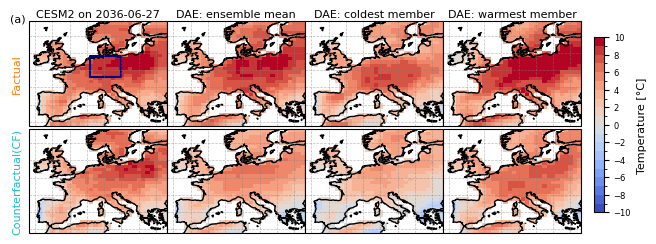

In [4]:
fact_dae_mean = dae_eth_fact.TREFHT.mean(dim="ensemble_member")
cf_dae_mean = dae_eth_cf.TREFHT.mean(dim="ensemble_member")

# Example dataset: ds.TREFHT should exist
date = 3539 #=year 2036
date_text = "2036-06-27"
print("Date:", ds_test_eth_fact.TREFHT.isel(time=date).time.values)

# Factual Fields
# find min and max values of domain average temperature
imin_fact = (
    dae_eth_ens_spatial_mean
    .isel(time=date)
    .argmin(dim="ensemble_member")
)
imax_fact = (
    dae_eth_ens_spatial_mean
    .isel(time=date)
    .argmax(dim="ensemble_member")
)

field_factual = ds_test_eth_fact.TREFHT.isel(time=date)
field_1 = fact_dae_mean.isel(time=date)
field_2 = dae_eth_fact.TREFHT.isel(ensemble_member = imin_fact, time=date)
field_3 = dae_eth_fact.TREFHT.isel(ensemble_member = imax_fact, time=date)

# Counterfactual Fields

# find min and max values of domain average temperature
imin_cf = (
    dae_eth_ens_spatial_mean_cf
    .isel(time=date)
    .argmin(dim="ensemble_member")
)
imax_cf = (
    dae_eth_ens_spatial_mean_cf
    .isel(time=date)
    .argmax(dim="ensemble_member")
)

field_cf = ds_test_eth_cf.TREFHT.isel(time=date)
field_1_cf = cf_dae_mean.isel(time=date)
field_2_cf = dae_eth_cf.TREFHT.isel(ensemble_member = imin_cf, time=date)
field_3_cf = dae_eth_cf.TREFHT.isel(ensemble_member = imax_cf, time=date)

# Plot parameters
vmin = -10
vmax = 10
no_levels=21
levels = np.linspace(vmin,vmax,no_levels)
cmap = "coolwarm"

text_fs = 8

# GER domain
ger_lat_min = 48
ger_lat_max = 54
ger_lon_min = 6
ger_lon_max = 15


# Create figure and subplots
fig, axes = plt.subplots(
    2, 4,
    subplot_kw={'projection': ccrs.PlateCarree()},
    figsize=(6.5,2.5)#(14, 6)
)


titles = [f"CESM2 on {date_text}", "DAE: ensemble mean", "DAE: coldest member", "DAE: warmest member", "", "", "", ""]
fields = [field_factual, field_1, field_2, field_3, field_cf, field_1_cf, field_2_cf, field_3_cf]
axes = axes.flatten()

for ax, field, title in zip(axes, fields, titles):
    pc = field.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        levels=levels,
        add_colorbar=False
    )
    

    if ax == axes[0]:
        lons = [ger_lon_min, ger_lon_max, ger_lon_max, ger_lon_min, ger_lon_min]
        lats = [ger_lat_min, ger_lat_min, ger_lat_max, ger_lat_max, ger_lat_min]
        ax.plot(
            lons, lats,
            transform=ccrs.PlateCarree(),
            color="navy",
            linewidth=1.5,
            linestyle="-"
        )
    ax.coastlines(resolution="50m", linewidth=1)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5)
    gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    ax.set_title(title, fontsize=text_fs, pad=3)


# tighten the grid (no whitespace)
fig.subplots_adjust(left=0.03, right=0.88, bottom=0.06, top=0.92,
                    wspace=0.0, hspace=0.0)

# create a dedicated axis for the colorbar: [left, bottom, width, height]
cax = fig.add_axes([0.90, 0.15, 0.015, 0.7])

cbar = fig.colorbar(pc, cax=cax, orientation="vertical")
cbar.set_label("Temperature [°C]", fontsize=text_fs)
cbar.set_ticks(levels)
cbar.ax.tick_params(labelsize=6)

# Set tick positions
cbar.set_ticks(np.linspace(-10,10,11))

axes[0].text(-0.125, 0.5, f'Factual', transform=axes[0].transAxes,
              fontsize=text_fs, rotation=90, color="tab:orange", verticalalignment='center', horizontalalignment='left', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
axes[4].text(-0.125, 0.5, f'Counterfactual(CF)', transform=axes[4].transAxes,
              fontsize=text_fs, rotation=90, color="tab:cyan", verticalalignment='center', horizontalalignment='left', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
axes[0].text(-0.135,1,"(a)", transform=axes[0].transAxes, fontsize=text_fs)

fig.subplots_adjust(wspace=0.0, hspace=0.0)
#plt.savefig(f"dpa_field_sample_{date_text}.pdf")
plt.show()


## Timeseries

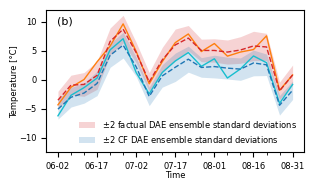

In [5]:
### Factual ###
year_tp = 2036
fig, ax = evaluation.plot_multiple_dpa_time_series(true_t = ds_test_eth_cf.TREFHT.isel(time=slice(0,4769)), 
                                          dpa_ens = dae_eth_cf.TREFHT.isel(time=slice(0,4769)), 
                                          dpa_ens_mean = cf_dae_mean.isel(time=slice(0,4769)),  
                                          true_t_fact = ds_test_eth_fact.TREFHT.isel(time=slice(0,4769)),
                                          dpa_ens_fact = dae_eth_fact.isel(time=slice(0,4769)),
                                          dpa_ens_mean_fact = fact_dae_mean.isel(time=slice(0,4769)),
                                          lat_min = ger_lat_min, 
                                          lat_max = ger_lat_max, 
                                          lon_min = ger_lon_min, 
                                          lon_max = ger_lon_max, 
                                          plot_year = [str(year_tp)],
                                          figsize_ts = (3.25,2),
                                          title_fontsize = 6,
                                          title = f"Factual Temperatures Germany {year_tp}", 
                                          climate = "Counterfactual"
                                          )

### add factual time series ###
temp_true_ger_pre = ds_test_eth_fact.TREFHT.isel(time=slice(0,4769)).sel(lat=slice(ger_lat_min, ger_lat_max), lon=slice(ger_lon_min, ger_lon_max))

# create weights
# 1) define weights as above
weights_ger = np.cos(np.deg2rad(temp_true_ger_pre['lat']))

# 2) wrap in a DataArray so xarray knows which dim it belongs to
w_da_ger = xr.DataArray(weights_ger, coords={'lat': temp_true_ger_pre['lat']}, dims=['lat'])

temp_true_ger = temp_true_ger_pre.weighted(w_da_ger).mean(dim=('lat', 'lon'))

ax.set_ylabel("Temperature [°C]", fontsize = 6, labelpad=0)
ax.set_xlabel("Time", fontsize=6, labelpad=0)
ax.text(0.04,0.9,"(b)", transform=ax.transAxes, fontsize=text_fs)
plt.tick_params(axis='both', which='major', labelsize=6)
plt.ylim(-12.5,12)
plt.tight_layout()

# title
#plt.title(f"Mean temperatures Germany {year_tp}", fontsize=6)
#plt.legend()
#plt.savefig(f"example_dpa_time_series_{year_tp}.pdf")
plt.show()

dae_ens_ger_1300: (1, 100)


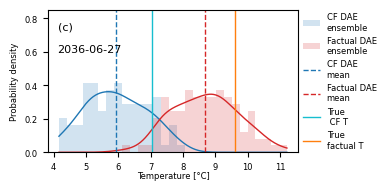

In [6]:


year = "2036"
dae_ens = dae_eth_cf.TREFHT.isel(time=slice(0,4769)).sel(time=slice(year,year))
dae_ens_fact = dae_eth_fact.isel(time=slice(0,4769)).sel(time=slice(year,year))

dae_ens_mean = cf_dae_mean.isel(time=slice(0,4769)).sel(time=slice(year,year))
dae_ens_mean_fact = fact_dae_mean.isel(time=slice(0,4769)).sel(time=slice(year,year))


lat_min = ger_lat_min 
lat_max = ger_lat_max
lon_min = ger_lon_min 
lon_max = ger_lon_max 
date=date_text

# ensemble mean, germany mean 
dae_ens_mean_ger = dae_ens_mean.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).sel(time=date).weighted(w_da_ger).mean(dim=('lat', 'lon'))

# ensemble germany average (ensemble_member, )
dae_ens_ger_1300 = dae_ens.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).sel(time=date).weighted(w_da_ger).mean(dim=('lat', 'lon'))
print("dae_ens_ger_1300:", dae_ens_ger_1300.values.T.shape)

# counterfactual truth
true_t = ds_test_eth_cf.TREFHT.isel(time=slice(0,4769)).sel(time=date)
cf_truth_ger = true_t.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).weighted(w_da_ger).mean(dim=('lat', 'lon'))




# ensemble mean, germany mean 
dae_ens_mean_ger_fact = dae_ens_mean_fact.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).sel(time=date).weighted(w_da_ger).mean(dim=('lat', 'lon'))

# ensemble germany average (ensemble_member, )
dae_ens_ger_1300_fact = dae_ens_fact.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).sel(time=date).TREFHT.weighted(w_da_ger).mean(dim=('lat', 'lon'))

# factual truth
true_t_fact = ds_test_eth_fact.TREFHT.isel(time=slice(0,4769)).sel(time=date)
fact_truth_ger = true_t_fact.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).weighted(w_da_ger).mean(dim=('lat', 'lon'))


# Example data (replace with your own arrays)
a = dae_ens_ger_1300.values.flatten()
b = dae_ens_ger_1300_fact.values.flatten()

# Common bins
bins = np.linspace(
    min(a.min(), b.min()),
    max(a.max(), b.max()),
    30
)

fig, ax = plt.subplots(figsize=(4,2))

# Histograms (normalized)
ax.hist(
    a, bins=bins, density=True, #histtype="step",
     linewidth=1.5,
    label="CF DAE\nensemble", color="tab:blue", alpha=0.2
)
ax.hist(
    b, bins=bins, density=True, #histtype="step",
     linewidth=1.5,
    label="Factual DAE\nensemble", color="tab:red", alpha=0.2
)

# KDEs
x = np.linspace(bins[0], bins[-1], 500)
kde_a = gaussian_kde(a)
kde_b = gaussian_kde(b)

ax.plot(x, kde_a(x), linewidth=1, color="tab:blue")
ax.plot(x, kde_b(x), linewidth=1, color="tab:red")



# mean values
ax.axvline(
    x=dae_ens_mean_ger.values,
    ymin=0.0,
    ymax=1.0,
    color="tab:blue",
    linestyle="--",
    linewidth=1.0,
    label="CF DAE\nmean"
)

ax.axvline(
    x=dae_ens_mean_ger_fact.values,
    ymin=0.0,
    ymax=1.0,
    color="tab:red",
    linestyle="--",
    linewidth=1.0,
    label="Factual DAE\nmean"
)



ax.axvline(
    x=cf_truth_ger.values,
    ymin=0.0,
    ymax=1.0,
    color="tab:cyan",
    linestyle="-",
    linewidth=1.0,
    label="True\n CF T"
)

ax.axvline(
    x=fact_truth_ger.values,
    ymin=0.0,
    ymax=1.0,
    color="tab:orange",
    linestyle="-",
    linewidth=1.0,
    label="True\nfactual T"
)



# Labels and legend
ax.set_xlabel("Temperature [°C]", fontsize=6, labelpad=0)
ax.set_ylabel("Probability density", fontsize=6)
ax.tick_params(axis="x", labelsize=6)
ax.tick_params(axis="y", labelsize=6)
ax.text(0.04,0.7,f"(c)\n\n{date}", transform=ax.transAxes, fontsize=text_fs)


ax.legend(
    loc="center left",
    bbox_to_anchor=(0.99, 0.5),
    frameon=False,
    fontsize=6
)

fig.subplots_adjust(right=0.75)

#ax.set_xlim(-1,5)
ax.set_ylim(0.0, 0.85)

plt.tight_layout()
#plt.savefig(f"T_distrs_{date_text}.pdf")
plt.show()
